<a href="https://colab.research.google.com/github/ivan-block/Traffic-signs-classification/blob/main/traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os
import seaborn as sns

from keras import layers, models
from keras.preprocessing import image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [59]:
zip_path = "traffic.zip"
extract_path = "traffic_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)
print("Folders:", os.listdir(extract_path))

Extracted to: traffic_data
Folders: ['traffic']


In [60]:
img_size = (224, 224)
batch_size = 32

traffic = tf.keras.preprocessing.image_dataset_from_directory(
    'traffic_data/traffic',
    image_size=img_size,
    batch_size=batch_size
)
class_names = traffic.class_names
print("Classes:", class_names)

all_image_paths = []
all_image_labels = []

for i, class_name in enumerate(class_names):
    class_dir = os.path.join("traffic_data/traffic", class_name)
    for fname in os.listdir(class_dir):
        all_image_paths.append(os.path.join(class_dir, fname))
        all_image_labels.append(i) # Assign numerical label (0 for Green, 1 for Red)

print(f"Total images found: {len(all_image_paths)}")
print(f"Total labels found: {len(all_image_labels)}")

Found 200 files belonging to 2 classes.
Classes: ['Green', 'Red']
Total images found: 200
Total labels found: 200


In [61]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_image_labels, test_size=0.3, random_state=42, stratify=all_image_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Training images: {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")
print(f"Test images: {len(test_paths)}")

Training images: 140
Validation images: 30
Test images: 30


In [62]:
# Helper function to load and preprocess images for the tf.data.Dataset
def preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = img / 255.0 # Normalize pixel values
    return img, label

# Create tf.data.Dataset objects
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000).batch(batch_size).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

print("New training dataset created: train_ds")
print("New validation dataset created: val_ds")
print("New test dataset created: test_ds")

New training dataset created: train_ds
New validation dataset created: val_ds
New test dataset created: test_ds


Now you have `train_ds`, `val_ds`, and `test_ds` which you can use for model training and evaluation.

**Note:** If you want to use these new datasets for training, you'll need to re-run the model compilation and fitting cells, replacing `train_data` and `val_data` with `train_ds` and `val_ds` respectively.

In [63]:
traffic = tf.keras.preprocessing.image_dataset_from_directory(
    'traffic_data/traffic',
    image_size=img_size,
    batch_size=batch_size
)

class_names = traffic.class_names
print("Classes:", class_names)

Found 200 files belonging to 2 classes.
Classes: ['Green', 'Red']


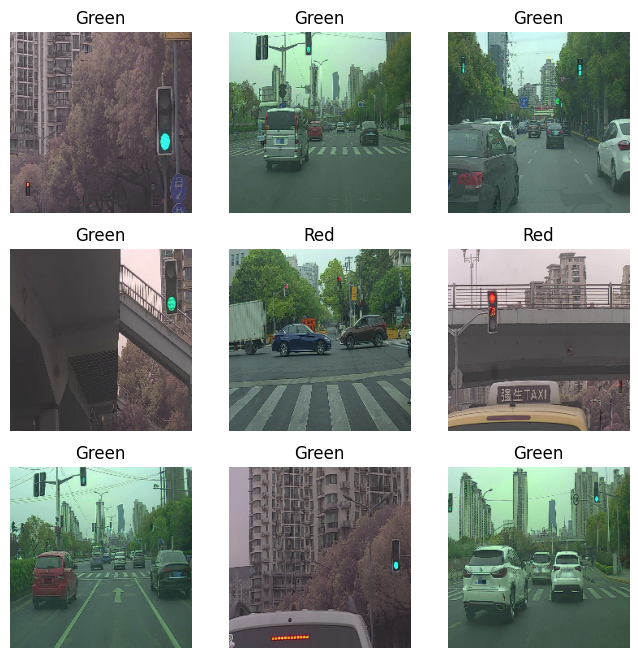

In [64]:
plt.figure(figsize=(8, 8))

for images, labels in traffic.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [65]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
])

In [66]:
model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

## Transfer Learning with MobileNetV2

## Transfer Learning with ResNet50

In [67]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [68]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 37s 6s/step - accuracy: 0.5929 - loss: 2.1012 - val_accuracy: 0.5000 - val_loss: 0.7096
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 39s 6s/step - accuracy: 0.4857 - loss: 0.7099 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.5071 - loss: 0.6930 - val_accuracy: 0.4667 - val_loss: 0.6933
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.5714 - loss: 0.6915 - val_accuracy: 0.6000 - val_loss: 0.6920
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.5929 - loss: 0.6885 - val_accuracy: 0.4000 - val_loss: 0.6916
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 32s 6s/step - accuracy: 0.6071 - loss: 0.6854 - val_accuracy: 0.5333 - val_loss: 0.6854
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.5214 - loss: 0.6839 - val_accuracy: 0.6667 - val_loss: 0.6834
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.6286 - loss: 0.6696 - val_accuracy: 0.5667 - val_loss: 0.6716
Epoch 9/

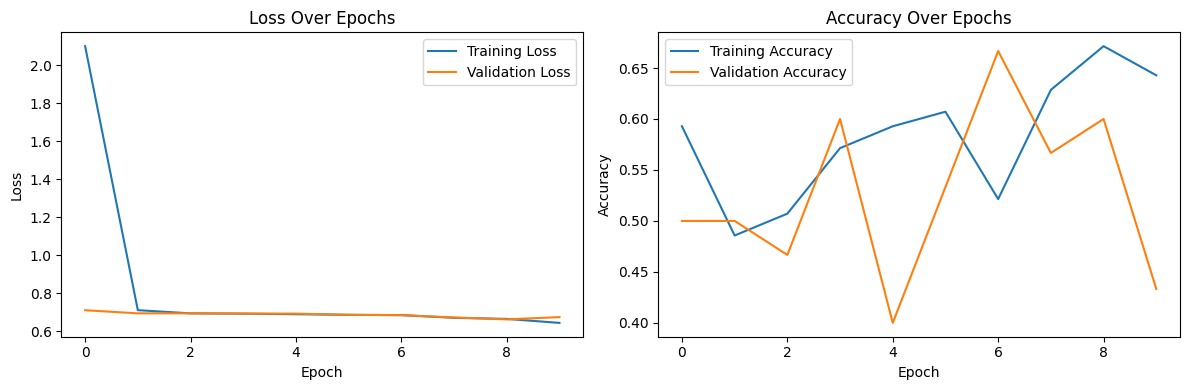

In [69]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [70]:
model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4333 - loss: 0.6734


[0.6733865141868591, 0.4333333373069763]

In [71]:
print("Evaluating model on the test dataset:")
model.evaluate(test_ds)

Evaluating model on the test dataset:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7000 - loss: 0.5945


[0.5945016145706177, 0.699999988079071]

In [72]:
print("\nMaking predictions on a batch from the test dataset:")
for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    for i in range(len(labels)):
        predicted_class_idx = (predictions[i] > 0.5).astype(int)[0]
        predicted_label = class_names[predicted_class_idx]
        true_label = class_names[labels[i].numpy()]
        print(f"Image {i+1}: Predicted: {predicted_label}, True: {true_label}")


Making predictions on a batch from the test dataset:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Image 1: Predicted: Green, True: Green
Image 2: Predicted: Red, True: Green
Image 3: Predicted: Green, True: Green
Image 4: Predicted: Red, True: Green
Image 5: Predicted: Red, True: Red
Image 6: Predicted: Red, True: Red
Image 7: Predicted: Red, True: Green
Image 8: Predicted: Green, True: Green
Image 9: Predicted: Red, True: Red
Image 10: Predicted: Green, True: Green
Image 11: Predicted: Red, True: Green
Image 12: Predicted: Red, True: Red
Image 13: Predicted: Red, True: Red
Image 14: Predicted: Red, True: Green
Image 15: Predicted: Red, True: Red
Image 16: Predicted: Green, True: Green
Image 17: Predicted: Red, True: Red
Image 18: Predicted: Red, True: Green
Image 19: Predicted: Red, True: Green
Image 20: Predicted: Red, True: Red
Image 21: Predicted: Red, True: Red
Image 22: Predicted: Red, True: Green
Image 23: Predicted: Red, True: Red
Image 24: Predicted: Red, True: Red
Image 25: Predicted

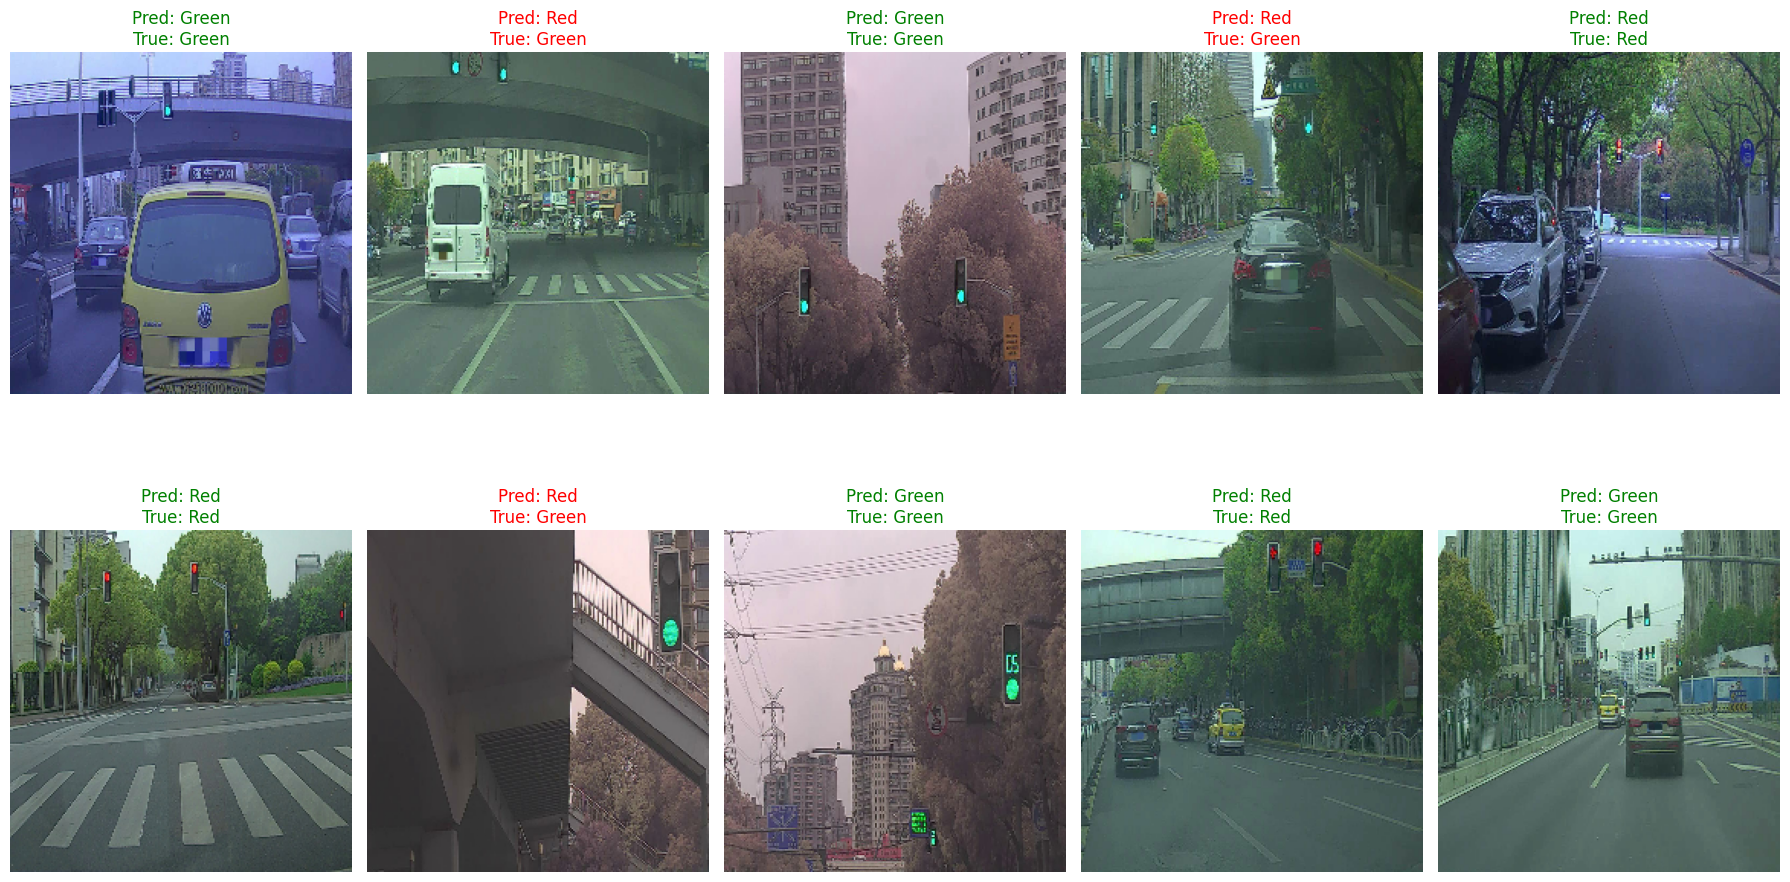

In [73]:
num_images_to_display = 10 # You can change this number

plt.figure(figsize=(18, 48))

# Take one batch from the test_ds
for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)

    for i in range(num_images_to_display):
        plt.subplot(num_images_to_display, 5, i + 1) # Adjust subplot grid dynamically
        plt.imshow(images[i].numpy())

        predicted_class_idx = (predictions[i] > 0.5).astype(int)[0]
        predicted_label = class_names[predicted_class_idx]
        true_label = class_names[labels[i].numpy()]

        color = "green" if predicted_label == true_label else "red"
        plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()

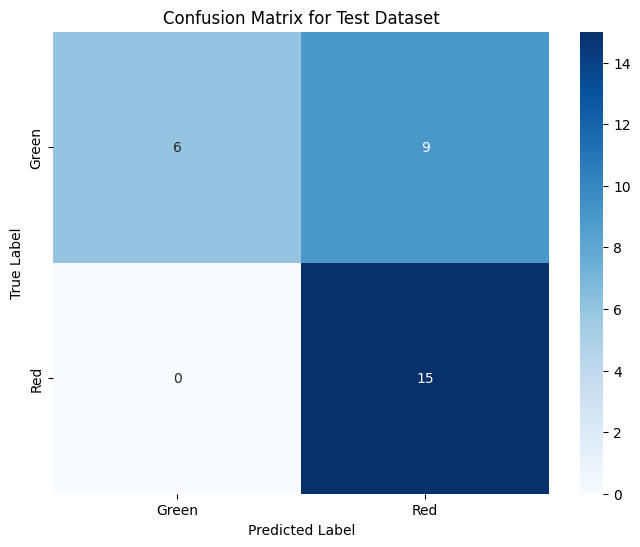

In [74]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = (predictions > 0.5).astype(int).flatten()
    y_pred.extend(predicted_classes)
    y_true.extend(labels.numpy())

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Dataset')
plt.show()

Found 9 misclassified images.


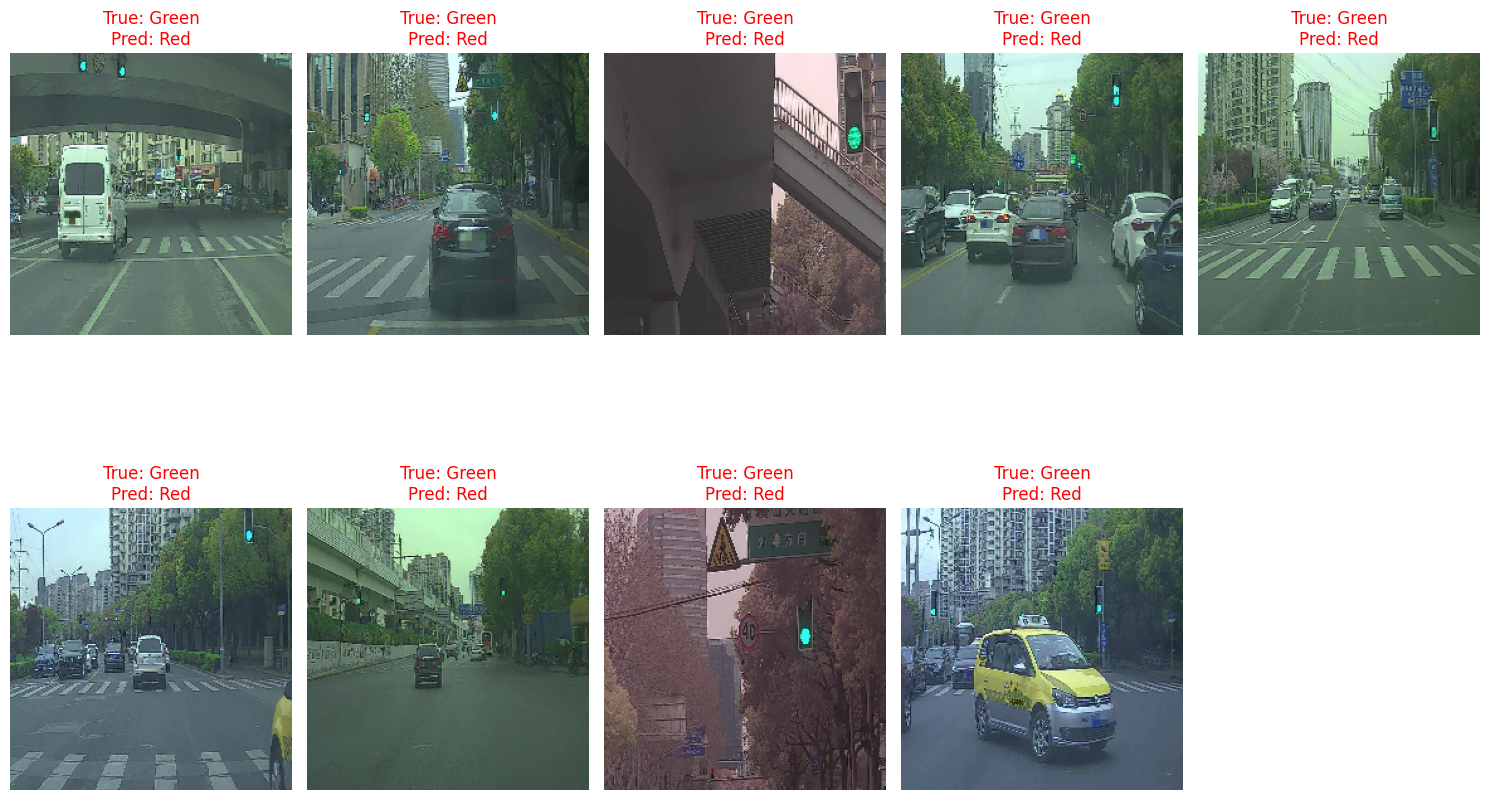

In [75]:
# Find misclassified indices
misclassified_indices = np.where(np.array(y_true) != np.array(y_pred))[0]

if len(misclassified_indices) == 0:
    print("No misclassified images found in the test set.")
else:
    print(f"Found {len(misclassified_indices)} misclassified images.")

    # Display misclassified images
    plt.figure(figsize=(15, 5 * ((len(misclassified_indices) + 4) // 5)))
    for i, idx in enumerate(misclassified_indices):
        img_path = test_paths[idx]
        true_label = class_names[y_true[idx]]
        predicted_label = class_names[y_pred[idx]]

        img = image.load_img(img_path, target_size=img_size)
        img_array = image.img_to_array(img)

        plt.subplot((len(misclassified_indices) + 4) // 5, 5, i + 1)
        plt.imshow(img_array.astype('uint8'))
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color='red')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [76]:
report = classification_report(y_true, y_pred, target_names=class_names)
acc = accuracy_score(y_true, y_pred)

print(f"Accuracy: {acc:.3f}")
print("Classification Report:\n", report)

Accuracy: 0.700
Classification Report:
               precision    recall  f1-score   support

       Green       1.00      0.40      0.57        15
         Red       0.62      1.00      0.77        15

    accuracy                           0.70        30
   macro avg       0.81      0.70      0.67        30
weighted avg       0.81      0.70      0.67        30



In [77]:
from keras.applications import MobileNetV2
from keras.optimizers import Adam

# Load the MobileNetV2 model with pre-trained ImageNet weights, excluding the top classification layer
base_model_mobilenet = MobileNetV2(input_shape=(img_size[0], img_size[1], 3),
                                   include_top=False,
                                   weights='imagenet')

# Freeze the layers of the base model so they are not updated during training
base_model_mobilenet.trainable = False

# Create a new model on top of the pre-trained base
mobilenet_model = models.Sequential([
    data_augmentation, # Apply data augmentation
    base_model_mobilenet,
    layers.GlobalAveragePooling2D(), # Use GlobalAveragePooling2D instead of Flatten for feature extraction
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the MobileNetV2 model
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001), # Use a lower learning rate for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training MobileNetV2 model...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5143 - loss: 0.8989 - val_accuracy: 0.5667 - val_loss: 0.7412
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6429 - loss: 0.7071 - val_accuracy: 0.5000 - val_loss: 0.7376
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5500 - loss: 0.8039 - val_accuracy: 0.5333 - val_loss: 0.7208
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6429 - loss: 0.6663 - val_accuracy: 0.5333 - val_loss: 0.7022
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6429 - loss: 0.6210 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6429 - loss: 0.6539 - val_accuracy: 0.5333 - val_loss: 0.6845
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6929 - loss: 0.5819 - val_accuracy: 0.5000 - val_loss: 0.6611
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7357 - loss: 0.5347 - val_accuracy: 0.5667

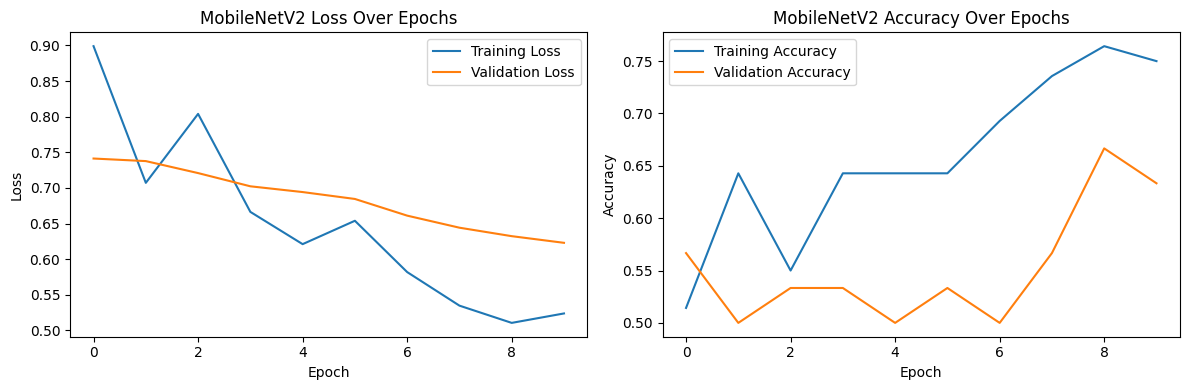

In [79]:
print("Training MobileNetV2 model...")
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Plot training history for MobileNetV2
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mobilenet_history.history['accuracy'], label='Training Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [81]:
print("Evaluating MobileNetV2 model on the test dataset...")
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(test_ds)
print(f"MobileNetV2 Test Loss: {mobilenet_test_loss:.4f}")
print(f"MobileNetV2 Test Accuracy: {mobilenet_test_accuracy:.4f}")

Evaluating MobileNetV2 model on the test dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8667 - loss: 0.4505
MobileNetV2 Test Loss: 0.4505
MobileNetV2 Test Accuracy: 0.8667
